In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import random
from collections import defaultdict
import os
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# download the VOC dataset
train_dataset = torchvision.datasets.VOCDetection(
    root='./data',
    year='2007',
    image_set='train',
    download=True
)

# group image IDs by their category for episode sampling.
class_to_indices = defaultdict(list)
for i in range(len(train_dataset)):
    _, target = train_dataset[i]
    objects = target['annotation']['object']
    if not isinstance(objects, list):
        objects = [objects]
    for obj in objects:
        cls = obj['name']
        class_to_indices[cls].append(i)

In [1]:
#custom class for our episodic data
#each episode contains support image,support mask,query image, actual /GT mask

class VOCEpisodicDataset(Dataset):
    def __init__(self, dataset, class_to_indices, transform, K=1):
        self.dataset = dataset
        self.class_to_indices = class_to_indices
        self.classes = list(class_to_indices.keys())
        self.transform = transform
        self.K = K

    def __len__(self):
        return 5000

    def __getitem__(self, idx):
        #  a random object class and use its images to create a new one-shot task.
        cls = random.choice(self.classes)
        indices = self.class_to_indices[cls]
        sampled = random.sample(indices, self.K + 1)
        support_ids = sampled[:self.K]
        query_id = sampled[-1]

        support_imgs, support_masks = [], []
        for sid in support_ids:
            img, target = self.dataset[sid]
            mask = self.create_class_mask(target, cls, img.size[0], img.size[1])
            support_imgs.append(self.transform(img))
            support_masks.append(mask)

        query_img, target = self.dataset[query_id]
        query_mask = self.create_class_mask(target, cls, query_img.size[0], query_img.size[1])
        return torch.stack(support_imgs), torch.stack(support_masks), self.transform(query_img), query_mask

    def create_class_mask(self, target, cls, orig_w, orig_h):
        # Generate a binary mask from the bounding box data specifically for the target class.
        mask = torch.zeros((1, 224, 224))
        objects = target['annotation']['object']
        if not isinstance(objects, list): objects = [objects]
        for obj in objects:
            if obj['name'] != cls: continue
            bbox = obj['bndbox']
            x1, y1 = int(float(bbox['xmin'])/orig_w*224), int(float(bbox['ymin'])/orig_h*224)
            x2, y2 = int(float(bbox['xmax'])/orig_w*224), int(float(bbox['ymax'])/orig_h*224)
            mask[:, y1:y2, x1:x2] = 1
        return mask
        
# Initialize the dataloader to serve batches of these episodes during training.
dataloader = DataLoader(VOCEpisodicDataset(train_dataset, class_to_indices, transform), batch_size=8, shuffle=True)

In [2]:
# Our feature extractor based on ResNet-50; we freeze the first two layers to keep standard visual 
# features intact while fine-tuning the deeper layers for our specific task.
class Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = torchvision.models.resnet50(weights='IMAGENET1K_V1')
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        
        for p in self.layer0.parameters(): p.requires_grad = False
        for p in self.layer1.parameters(): p.requires_grad = False

    def forward(self, x):
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        f3 = self.layer3(x) 
        f4 = self.layer4(f3) 
        return f3, f4

# This module computes the point-to-point similarity between the query and support features.
# It uses the support mask to focus only on the target object and find its best matches in the query image.
class SimilarityGuidanceModule(nn.Module):
    def forward(self, support_feat, support_mask, query_feat):
        B, C, H, W = query_feat.shape
        mask = F.interpolate(support_mask, size=(H, W), mode="nearest")
        
        q_flat = F.normalize(query_feat.view(B, C, -1), dim=1) 
        s_flat = F.normalize(support_feat.view(B, C, -1), dim=1) 
        
        correlation = torch.bmm(q_flat.transpose(1, 2), s_flat)
        correlation = correlation * mask.view(B, 1, -1)
        
        sim_map, _ = correlation.max(dim=2)
        return sim_map.view(B, 1, H, W)

# The main model that brings everything together. It takes the similarity map and 
# combines it with original query features to draw a precise final mask.
class SILCOLocalizer(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = Backbone()
        self.sgm = SimilarityGuidanceModule()
        self.head = nn.Sequential(
            nn.Conv2d(2048 + 1, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, 1)
        )

    def forward(self, support_imgs, support_masks, query_img):
        _, s_feat4 = self.backbone(support_imgs)
        _, q_feat4 = self.backbone(query_img)
        sim = self.sgm(s_feat4, support_masks, q_feat4)
        combined = torch.cat([q_feat4, sim], dim=1)
        return self.head(combined)

In [3]:
# The Dice Loss handles the overlap between predicted and actual masks, 
# useful for segmenting objects of various sizes.
def dice_loss(pred, target, smooth=1.):
    pred = torch.sigmoid(pred)
    if target.dim() == 3: target = target.unsqueeze(1)
    intersection = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    return 1 - ((2.*intersection + smooth) / (union + smooth)).mean()

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SILCOLocalizer().to(device)

optimizer = torch.optim.Adam([
    {"params": model.backbone.parameters(), "lr": 1e-5},
    {"params": model.head.parameters(), "lr": 1e-4}
])

# Automatically lower the learning rate if the loss stops improving for the specified epochs(patience).
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

#binary cross entropy loss
criterion = torch.nn.BCEWithLogitsLoss()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 138MB/s] 


In [15]:
# rm -rf /kaggle/working/checkpoints

In [4]:
#resume from the latest checkpoint if it exists
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
checkpoint_path = os.path.join(CHECKPOINT_DIR, "latest.pth")
best_model_path = os.path.join(CHECKPOINT_DIR, "best.pth")

start_epoch = 0
best_loss = float('inf')

if os.path.exists(checkpoint_path):
    print("checkpoint exists?")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_loss = checkpoint['loss']
    print(f"Resumed from epoch {start_epoch}")
else:
    print("Fresh training")

checkpoint exists?
Resumed from epoch 30


In [5]:
#to calculate miou and accuracy
def calculate_metrics(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred) > threshold
    target = target > 0.5
    
    intersection = (pred & target).sum(dim=(1, 2, 3))
    union = (pred | target).sum(dim=(1, 2, 3))
    
    iou = (intersection.float() + 1e-6) / (union.float() + 1e-6)
    
    correct_pixels = (pred == target).sum(dim=(1, 2, 3))
    total_pixels = target.numel() / target.shape[0]
    accuracy = correct_pixels.float() / total_pixels
    
    return iou.mean().item(), accuracy.mean().item()

In [9]:

# The training loop 
for epoch in range(start_epoch, num_epochs):
    model.train()
    total_loss = 0
    total_iou = 0
    total_acc = 0
    
    # Process each batch of episodes
    for s_imgs, s_masks, q_img, gt_mask in dataloader:
        s_imgs = s_imgs.squeeze(1).to(device)
        s_masks = s_masks.squeeze(1).to(device)
        q_img, gt_mask = q_img.to(device), gt_mask.to(device)
        
        optimizer.zero_grad()
        pred = model(s_imgs, s_masks, q_img)
        pred = F.interpolate(pred, size=(224, 224), mode='bilinear', align_corners=False)
        
        # ' the BCE loss, which is added to the Dice loss for a stronger training objective.
        loss = criterion(pred, gt_mask) + dice_loss(pred, gt_mask)
        loss.backward()
        optimizer.step()
        
        #  tracking model performance to ensure something is being learnt
        batch_iou, batch_acc = calculate_metrics(pred.detach(), gt_mask)
        
        total_loss += loss.item()
        total_iou += batch_iou
        total_acc += batch_acc

    avg_loss = total_loss / len(dataloader)
    avg_iou = total_iou / len(dataloader)
    avg_acc = total_acc / len(dataloader)
    
    print(f"Epoch {epoch+1} Details: Loss: {avg_loss:.4f} , mIoU: {avg_iou:.4f} , accuracy: {avg_acc*100:.4f}")
    
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(), 'loss': avg_loss}, checkpoint_path)

    if avg_loss < best_loss:
        best_loss = avg_loss
        print('saved best model so far')
        torch.save(model.state_dict(), best_model_path)
    scheduler.step(avg_loss)

Epoch 21 Details: Loss: 0.2711 , mIoU: 0.7943 , accuracy: 96.1150
Epoch 22 Details: Loss: 0.2671 , mIoU: 0.7942 , accuracy: 96.1888
Epoch 23 Details: Loss: 0.2484 , mIoU: 0.8028 , accuracy: 96.5062
saved best model so far
Epoch 24 Details: Loss: 0.2592 , mIoU: 0.7991 , accuracy: 96.2890
Epoch 25 Details: Loss: 0.2608 , mIoU: 0.7969 , accuracy: 96.2810
Epoch 26 Details: Loss: 0.2548 , mIoU: 0.7987 , accuracy: 96.4569
Epoch 27 Details: Loss: 0.2624 , mIoU: 0.7966 , accuracy: 96.3489
Epoch 28 Details: Loss: 0.2576 , mIoU: 0.7998 , accuracy: 96.3049
Epoch 29 Details: Loss: 0.2492 , mIoU: 0.8029 , accuracy: 96.5004
Epoch 30 Details: Loss: 0.2428 , mIoU: 0.8070 , accuracy: 96.6313
saved best model so far


In [12]:
#evaluating model performance over 500 episodes 
def evaluate_model(model, dataloader, num_eval_episodes=500):
    model.eval()
    all_ious = []
    all_accs = []
    
    print(f"Evaluating over {num_eval_episodes} episodes")
    
    episodes_processed = 0
    with torch.no_grad():
        for s_imgs, s_masks, q_img, gt_mask in dataloader:
            if episodes_processed >= num_eval_episodes:
                break
                
            s_imgs = s_imgs.squeeze(1).to(device)
            s_masks = s_masks.squeeze(1).to(device)
            q_img, gt_mask = q_img.to(device), gt_mask.to(device)
            
            pred = model(s_imgs, s_masks, q_img)
            pred = F.interpolate(pred, size=(224, 224), mode='bilinear', align_corners=False)
            
            iou, acc = calculate_metrics(pred, gt_mask)
            all_ious.append(iou)
            all_accs.append(acc)
            
            episodes_processed += s_imgs.shape[0]

    print(f"Mean IoU (mIoU): {np.mean(all_ious):.4f}")
    print(f"Mean Pixel Accuracy: {np.mean(all_accs)*100:.2f}%")

evaluate_model(model, dataloader)

Evaluating over 500 episodes
Mean IoU (mIoU): 0.8138
Mean Pixel Accuracy: 96.91%


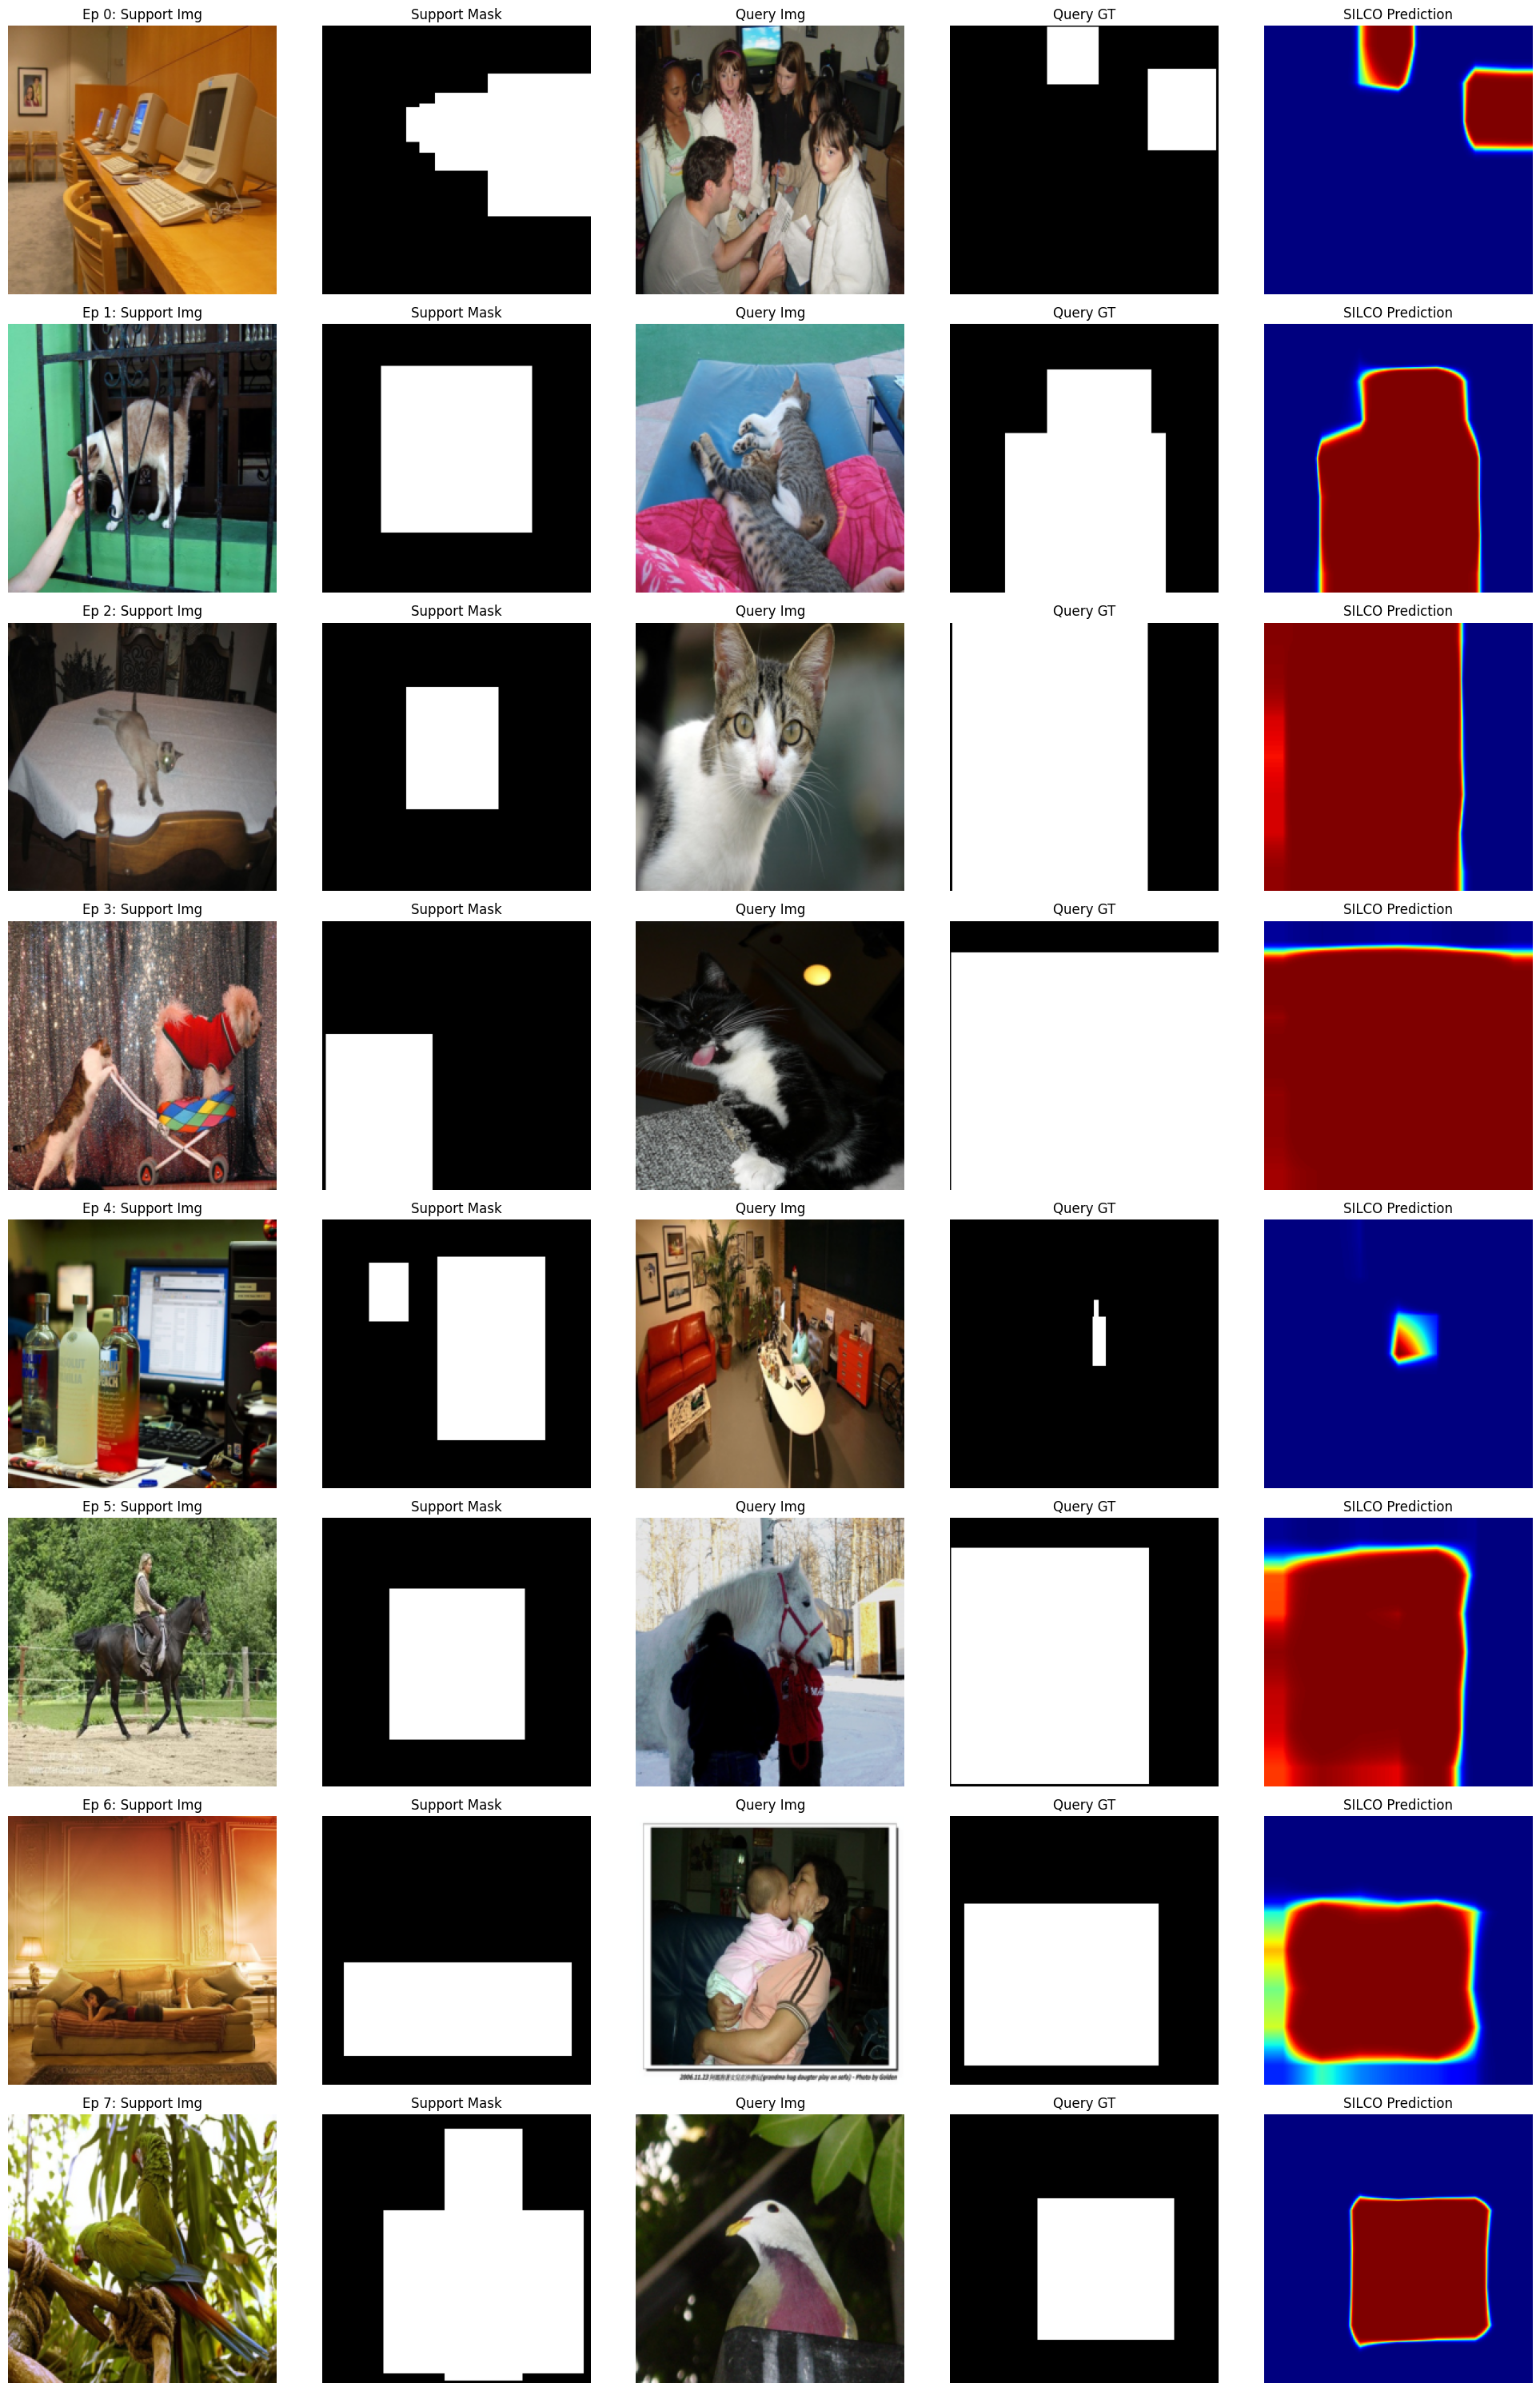

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    return np.clip(img, 0, 1)

model.eval()
(s_imgs, s_masks, q_img, gt_mask) = next(iter(dataloader))

s_imgs_v = s_imgs.squeeze(1).to(device)
s_masks_v = s_masks.squeeze(1).to(device)
q_img_v = q_img.to(device)

with torch.no_grad():
    logits = model(s_imgs_v, s_masks_v, q_img_v)
    pred_map = torch.sigmoid(F.interpolate(logits, size=(224, 224), mode='bilinear'))

fig, axes = plt.subplots(8, 5, figsize=(20, 30))

for i in range(8):
    axes[i, 0].imshow(denormalize(s_imgs_v[i]))
    axes[i, 0].set_title(f"Ep {i}: Support Img")
    
    axes[i, 1].imshow(s_masks_v[i, 0].cpu().numpy(), cmap='gray')
    axes[i, 1].set_title("Support Mask")
    
    axes[i, 2].imshow(denormalize(q_img_v[i]))
    axes[i, 2].set_title("Query Img")
    
    axes[i, 3].imshow(gt_mask[i, 0].cpu(), cmap='gray')
    axes[i, 3].set_title("Query GT")
    
=    axes[i, 4].imshow(pred_map[i, 0].cpu().numpy(), cmap='jet')
    axes[i, 4].set_title("SILCO Prediction")

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()